# Seb replay analysis — 5 games, 60k to 137k

Five wins from the top-ranked player, per-step CSVs (720 steps x 106 columns).

**Read this first — the engine our local tests use is NOT the engine these games were played on.**

| | local `kaggle_environments` 1.32.4 | live (1.32.6) |
|---|---|---|
| shop draw | `remaining = [s for s in SHOPS if s not in unlocked]` — **without replacement** | `rng.choice(sorted(SHOPS))`, cap `MAX_SHOP_INSTANCES = 8` — **with replacement** |
| consequence | every game ends with all 8 distinct shops; **milk demand is always exactly 3** | milk shops ~ Binomial(8, 3/8): varies **0-6** across games |
| LOCKED tiles | guard runs before shed ops | shed ops resolve first (3 of 4 shed-access tiles start LOCKED) |

Engine diff is **102 lines**. Any shop-adaptive strategy measured on 1.32.4 will show
~zero effect because there is nothing to adapt to. Upgrade before testing change #1.

In [1]:
import pandas as pd, numpy as np, glob, os
import matplotlib.pyplot as plt

FILES = sorted(glob.glob(os.path.expanduser(r"~/Downloads/seb_*.csv")))
games = {os.path.basename(f).split("_")[1]: pd.read_csv(f) for f in FILES}
MILK_SHOPS = {"PIZZA_SHOP", "ICE_CREAM_SHOP", "SMOOTHIE_SHOP"}
WOOL_SHOPS = {"YARN_STORE"}
I0 = 10_000
print({k: v.shape for k, v in games.items()})

{'128k': (720, 106), '137k': (720, 106), '59k': (720, 106), '60k': (720, 106), '93k': (720, 106)}


## 1. Shop draw — duplicates are real, and they are the independent variable

In [2]:
def shops_at(d, day):
    s = d[d.day == day]["shops"].dropna()
    return str(s.iloc[-1]).split("|") if len(s) else []

rows = []
for name, d in games.items():
    end = shops_at(d, 29)
    rows.append(dict(game=name,
        milk_d12=sum(s in MILK_SHOPS for s in shops_at(d, 12)),
        milk_end=sum(s in MILK_SHOPS for s in end),
        yarn_end=sum(s in WOOL_SHOPS for s in end),
        n_shops_end=len(end), distinct=len(set(end))))
shops = pd.DataFrame(rows).sort_values("milk_end")
shops

,game,milk_d12,milk_end,yarn_end,n_shops_end,distinct
3,60k,1,1,1,8,6
2,59k,0,2,1,8,6
4,93k,1,3,1,8,8
0,128k,4,4,0,8,5
1,137k,3,6,2,8,4


`n_shops_end` is 8 in every game while `distinct` is lower — that is the draw-with-replacement
signature. Our 1.32.4 would show `distinct == 8` always.

## 2. The finding: milk price is a step function of whether inventory crosses I0

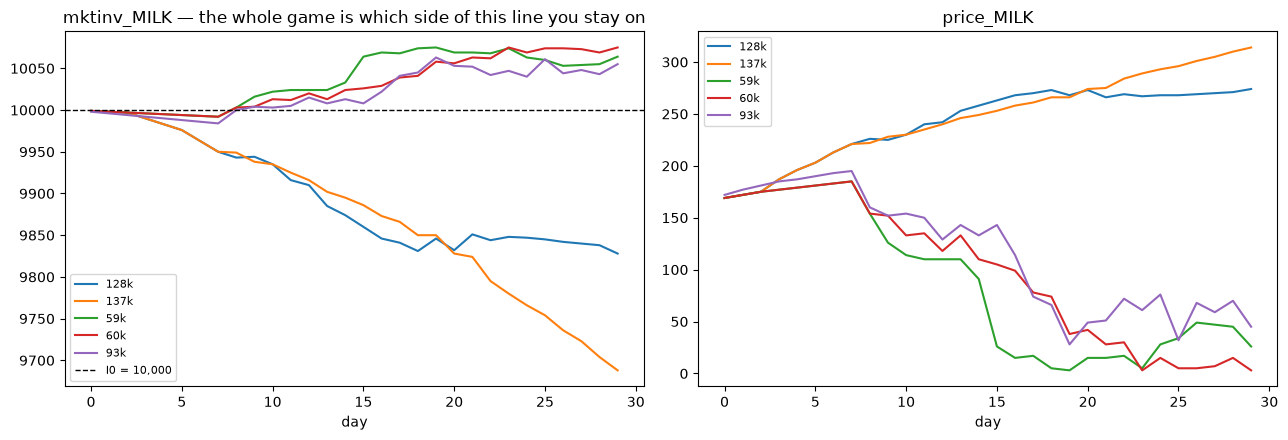

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for name, d in games.items():
    daily = d.groupby("day").last()
    ax[0].plot(daily.index, daily["mktinv_MILK"], label=name)
    ax[1].plot(daily.index, daily["price_MILK"], label=name)
ax[0].axhline(I0, color="k", ls="--", lw=1, label="I0 = 10,000")
ax[0].set_title("mktinv_MILK — the whole game is which side of this line you stay on")
ax[1].set_title("price_MILK")
for a in ax: a.set_xlabel("day"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [4]:
# MILK market params: base 160, I0 10000, scale 122, below sqrt/0.6, above LINEAR/1.6
# Above-I0 slope: 1.6 * 160 / 122 = $2.10 lost per unit of oversupply.
print(f"glut slope: ${1.6*160/122:.2f} per unit above I0")
print(f"75 units of oversupply -> ${160 - 75*1.6*160/122:.0f}")

glut slope: $2.10 per unit above I0
75 units of oversupply -> $3


## 3. Revenue decomposition — milk explains 87% of the score spread

In [5]:
PRODUCTS = ["MILK","WOOL","STRAWBERRY","MELON","WHEAT","EGG","FERTILIZER","CARROT","TOMATO"]
rows = []
for name, d in games.items():
    rev = {p: d["sellrev_"+p].sum() for p in PRODUCTS}
    units = {p: d["sell_"+p].sum() for p in PRODUCTS}
    rows.append(dict(game=name, score=int(d.iloc[-1]["money"]),
        cows=int(d.herd_COW.max()), sheep=int(d.herd_SHEEP.max()),
        milk_units=int(units["MILK"]),
        milk_price=round(rev["MILK"]/units["MILK"], 1) if units["MILK"] else 0,
        milk_rev=int(rev["MILK"]), wool_rev=int(rev["WOOL"]),
        straw_rev=int(rev["STRAWBERRY"]), total_rev=int(sum(rev.values()))))
rec = pd.DataFrame(rows).sort_values("score")
rec["milk_pct"] = (100*rec.milk_rev/rec.total_rev).round(1)
display(rec)
print(f"score spread   {rec.score.max()-rec.score.min():,}")
print(f"milk spread    {rec.milk_rev.max()-rec.milk_rev.min():,}"
      f"  = {100*(rec.milk_rev.max()-rec.milk_rev.min())/(rec.score.max()-rec.score.min()):.0f}% of it")

,game,score,cows,sheep,milk_units,milk_price,milk_rev,wool_rev,straw_rev,total_rev,milk_pct
2,59k,59910,7,11,138,47.8,6596,17163,37263,92062,7.2
3,60k,60347,7,12,157,72.0,11309,9329,45816,96447,11.7
4,93k,93620,9,9,228,83.5,19034,16662,50483,128254,14.8
0,128k,128518,13,8,303,262.8,79629,5458,53460,170412,46.7
1,137k,137616,11,10,271,273.2,74040,37599,36887,179724,41.2


score spread   77,706
milk spread    73,033  = 94% of it


**Caveat that matters:** n=5, observational. Milk revenue and score are near-collinear, but
Seb also *built more cows* in the high-demand games — so we cannot separate "high demand caused
high score" from "he adapted correctly and that caused it". The causal test is our own A/B, on
the right engine.

## 4. Did he adapt, and how fast?

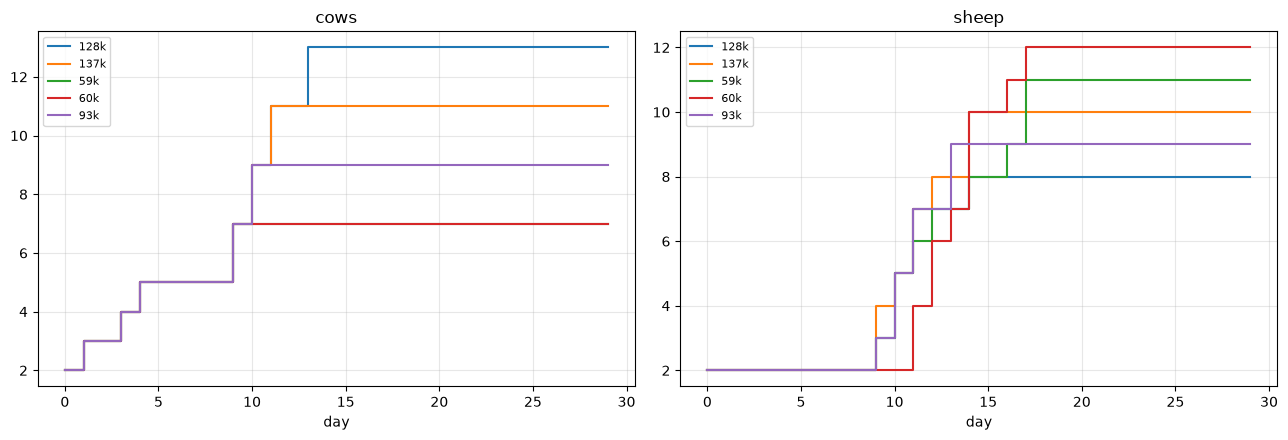

game  milk_d12  milk_end  cows  milk_price  score
 60k         1         1     7        72.0  60347
 59k         0         2     7        47.8  59910
 93k         1         3     9        83.5  93620
128k         4         4    13       262.8 128518
137k         3         6    11       273.2 137616


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for name, d in games.items():
    daily = d.groupby("day").last()
    ax[0].step(daily.index, daily["herd_COW"], where="post", label=name)
    ax[1].step(daily.index, daily["herd_SHEEP"], where="post", label=name)
ax[0].set_title("cows"); ax[1].set_title("sheep")
for a in ax: a.set_xlabel("day"); a.legend(fontsize=8); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

merged = shops.merge(rec, on="game")
print(merged[["game","milk_d12","milk_end","cows","milk_price","score"]]
      .sort_values("milk_end").to_string(index=False))

## 5. Land and structures

In [7]:
for name, d in games.items():
    buys = d[d.buy_land > 0]
    days = sorted(buys.day.unique().tolist())
    print(f"{name}: land bought on days {days} | "
          f"max structures {int(d.tiles_struct.max())} | "
          f"weeds at end {int(d.iloc[-1]['tiles_weed'])} | "
          f"max hands {int(d.hands.max())}")

128k: land bought on days [4, 6, 10] | max structures 21 | weeds at end 47 | max hands 12
137k: land bought on days [4, 6, 10] | max structures 21 | weeds at end 49 | max hands 12
59k: land bought on days [4, 6, 10] | max structures 18 | weeds at end 46 | max hands 12
60k: land bought on days [4, 6, 10] | max structures 19 | weeds at end 46 | max hands 12
93k: land bought on days [4, 6, 10] | max structures 18 | weeds at end 43 | max hands 12


## Conclusions

1. **Milk is a threshold game, not a linear one.** Stay below I0 and milk is $260-310/unit;
   cross it and the linear glut slope (-$2.10/unit) takes it to single digits. There is no
   middle ground in these five games.
2. **The correct control variable is `mktinv_MILK`, not the shop count.** Shop count is a proxy
   for how fast town demand drains inventory. A rule keyed directly on inventory versus I0
   generalises to wool, melon and strawberry, and needs no shop table at all.
3. **Herd size should follow demand**, but the measured evidence for the specific formula is
   weak (n=5, confounded). Test it as an A/B.
4. **Test on 1.32.6.** On 1.32.4 milk demand is a constant, so this entire effect is invisible.